<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT0011b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

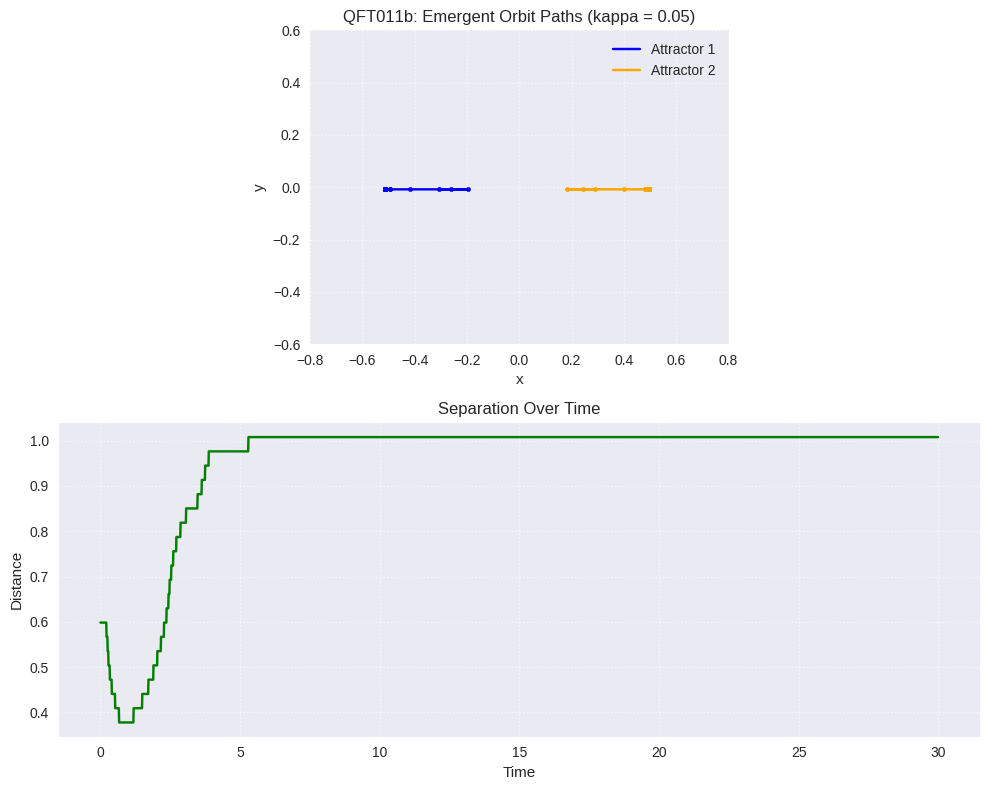

In [1]:
# QFT011b: Emergent Orbit Test — High Velocity Version
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass

# Parameters
N_grid = 128
T = 3000
dt = 0.01
delta = 0.10
gamma = 0.08
kappa = 0.05
v = 0.5  # high transverse velocity

# Grid setup
x = np.linspace(-1, 1, N_grid)
y = np.linspace(-1, 1, N_grid)
X, Y = np.meshgrid(x, y, indexing='ij')

# Initial positions
d = 0.6
x1, y1 = -d/2, 0.0
x2, y2 =  d/2, 0.0

# Gaussian attractors
def gaussian(x0, y0, sigma=0.05):
    return np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2)).astype(np.complex128)

psi1 = gaussian(x1, y1)
psi2 = gaussian(x2, y2)

# Impart transverse velocity via phase gradient
phase1 = np.exp(1j * Y * (+v * N_grid))
phase2 = np.exp(1j * Y * (-v * N_grid))
psi1 *= phase1
psi2 *= phase2

# Combine wavefunctions
psi = psi1 + psi2

# FFT Laplacian kernel
kx = np.fft.fftfreq(N_grid, d=(x[1] - x[0])) * 2 * np.pi
ky = np.fft.fftfreq(N_grid, d=(y[1] - y[0])) * 2 * np.pi
KX, KY = np.meshgrid(kx, ky, indexing='ij')
laplacian_kernel = -(KX**2 + KY**2)
implicit_denominator = 1 - dt * gamma * laplacian_kernel

# Trackers
com1_traj = []
com2_traj = []
sep_traj = []

# Evolution loop
for t in range(T):
    nonlinear = delta * np.abs(psi)**2 * psi
    restoring = -kappa * psi
    rhs = psi + dt * (nonlinear + restoring)

    rhs_fft = np.fft.fft2(rhs)
    psi_fft = rhs_fft / implicit_denominator
    psi = np.fft.ifft2(psi_fft)

    # Extract attractors via thresholding
    density = np.abs(psi)**2
    thresh = 0.5 * np.max(density)
    mask = density > thresh

    # Split mask into left and right halves
    mid = N_grid // 2
    mask1 = np.zeros_like(mask)
    mask2 = np.zeros_like(mask)
    mask1[:mid, :] = mask[:mid, :]
    mask2[mid:, :] = mask[mid:, :]

    com1 = center_of_mass(density * mask1)
    com2 = center_of_mass(density * mask2)

    x_com1, y_com1 = x[int(com1[0])], y[int(com1[1])]
    x_com2, y_com2 = x[int(com2[0])], y[int(com2[1])]

    com1_traj.append((x_com1, y_com1))
    com2_traj.append((x_com2, y_com2))

    sep = np.sqrt((x_com1 - x_com2)**2 + (y_com1 - y_com2)**2)
    sep_traj.append(sep)

# Convert to arrays
com1_traj = np.array(com1_traj)
com2_traj = np.array(com2_traj)
sep_traj = np.array(sep_traj)

# Plotting
plt.style.use('seaborn-v0_8')
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Orbital paths with scatter markers
axs[0].plot(com1_traj[:,0], com1_traj[:,1], label='Attractor 1', color='blue')
axs[0].plot(com2_traj[:,0], com2_traj[:,1], label='Attractor 2', color='orange')
axs[0].scatter(com1_traj[::100,0], com1_traj[::100,1], color='blue', s=10)
axs[0].scatter(com2_traj[::100,0], com2_traj[::100,1], color='orange', s=10)
axs[0].set_xlim(-0.8, 0.8)
axs[0].set_ylim(-0.6, 0.6)
axs[0].set_title('QFT011b: Emergent Orbit Paths (kappa = 0.05)')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].legend()
axs[0].grid(True, linestyle=':', alpha=0.6)
axs[0].set_aspect('equal')

# Separation over time
axs[1].plot(np.arange(T) * dt, sep_traj, color='green')
axs[1].set_title('Separation Over Time')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Distance')
axs[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
